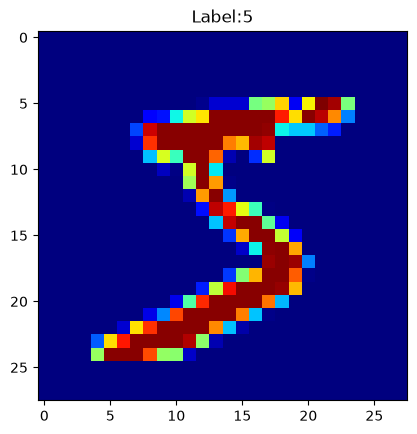

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [54]:
import cv2    #Used for loading, resizing, and processing images from your local system
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf   #Used as the core framework to build, train, and run deep learning models.
import numpy as np
from PIL import Image  #Used for opening, manipulating, and converting different image file formats easily--pil(pillow)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D,Dense,MaxPooling2D,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.math import confusion_matrix
tf.random.set_seed(3)

# Conv2D: Used to create layers that extract visual features like edges and shapes from images.
# Dense: Used to create fully connected layers that classify the extracted features into final categories.
# MaxPooling2D: Used to reduce image dimensions, which cuts down computational load and prevents overfitting.
# Flatten: Used to reshape multidimensional matrix data into a single long 1D vector.
# Sequential: Used to stack your neural network layers linearly from input to output.


(X_train,y_train),(X_test,y_test) = mnist.load_data()

plt.imshow(X_train[0],cmap='jet')
plt.title(f"Label:{y_train[0]}")
plt.show()

print(X_train[0])
print(f"RANGE:Before Divide:{X_train.max()},{X_train.min()}")


X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [55]:
print(X_train[0])
print(f"RANGE:After Divide:{X_train.max()},{X_train.min()}")

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [56]:
X_train = np.expand_dims(X_train,-1) ##MNIST image original (28, 28) yaani 2D format mein hoti hai, par TensorFlow ki Conv2D layer ko strictly 3D format (Width, Height, Channels) chahiye hota hai.
X_test = np.expand_dims(X_test,-1)

In [57]:
print(f"Shape of X_train:-{X_train.shape},shape of y_train:-{y_train.shape},shape of X_test:-{X_test.shape},shape of y_train:-{y_test.shape}")

Shape of X_train:-(60000, 28, 28, 1),shape of y_train:-(60000,),shape of X_test:-(10000, 28, 28, 1),shape of y_train:-(10000,)


In [58]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape = (28,28,1)),
    MaxPooling2D(((2,2))),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

c:\Users\rajan\OneDrive\Desktop\network-phishing-detector\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

my_callbacks = [
    EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
]

model.fit(X_train,y_train,epochs=3,batch_size=32,validation_split=0.1,verbose=1,callbacks=my_callbacks)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9462 - loss: 0.1817 - val_accuracy: 0.9797 - val_loss: 0.0743
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - accuracy: 0.9818 - loss: 0.0610 - val_accuracy: 0.9827 - val_loss: 0.0587
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9878 - loss: 0.0408 - val_accuracy: 0.9850 - val_loss: 0.0565


In [60]:
test_loss,test_acc = model.evaluate(X_test,y_test,verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}")

Test Accuracy: 98.38


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


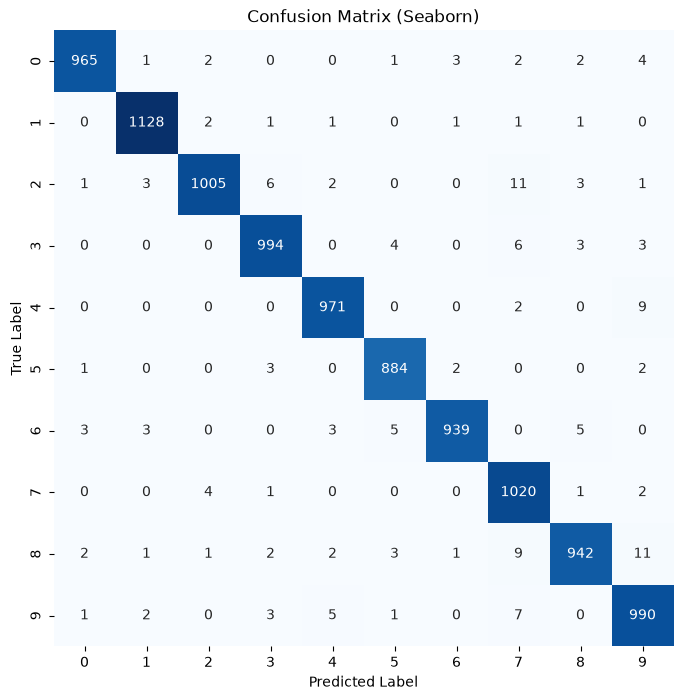

In [61]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred,axis=1)

cm = confusion_matrix(y_test,y_pred_label)

plt.figure(figsize=(8,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)
plt.xlabel("Predicted Label") 
plt.ylabel("True Label") 
plt.title("Confusion Matrix (Seaborn)") 
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Macro ROC AUC Score: 0.9998


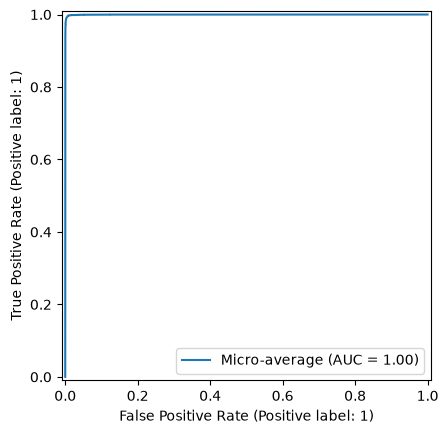

In [68]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

y_test_bin = label_binarize(y_test, classes=np.arange(10))
y_pred_probs = model.predict(X_test)
macro_roc_auc = roc_auc_score(y_test_bin, y_pred_probs, average='macro')
print(f"Macro ROC AUC Score: {macro_roc_auc:.4f}")


RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_pred_probs.ravel(), name="Micro-average")
plt.show()

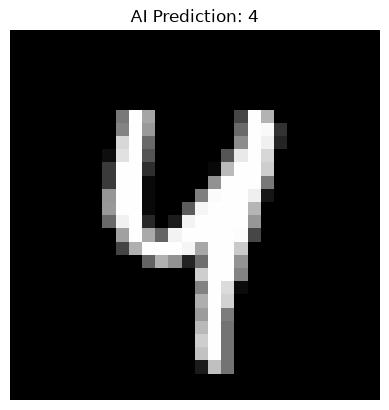

In [67]:
def predict_digit(raw_image):

    if raw_image.max() > 1.0:
        raw_image = raw_image / 255.0
        
    img = cv2.resize(raw_image, (28, 28))
    img_input = np.expand_dims(img, axis=(0, -1))
    predictions = model.predict(img_input, verbose=0)
    return np.argmax(predictions)


test_img = X_test[42].reshape(28, 28) 
ans = predict_digit(test_img)

plt.imshow(test_img, cmap="gray") 
plt.title(f"AI Prediction: {ans}") 
plt.axis("off")
plt.show()

In [ ]:
"""1. Objective & Dataset: Yeh project MNIST Handwritten Digits (0-9) ko classify karne ke liye ek Deep Learning pipeline hai, jisme data validation ke liye ROC AUC Curve aur Confusion Matrix ka use kiya gaya hai.
2. Data Preprocessing: Images ko float32 mein badalkar / 255.0 kiya gaya taaki pixels 0-1 range mein normalize ho sakein, aur np.expand_dims se channel dimension (1) add kiya kyunki Keras Conv2D strictly 3D input leta hai.
3. Model Architecture (CNN): Model mein Conv2D layers feature extract karti hain, MaxPooling2D image ka size half (aadha) karke computation kam karta hai, Flatten data ko 1D vector banata hai, aur aakhiri Dense(10) layer classes ko predict karti hai.
4. Compilation Settings: Model ko compile karne ke liye Adam optimizer (fast learning ke liye) aur sparse_categorical_crossentropy loss ka use kiya gaya hai, kyunki hamare target labels integers (0-9) hain, one-hot encoded nahi.
5. Overfitting Control: Training ke dauran EarlyStopping callback ka use kiya gaya hai, jo validation loss par nazar rakhta hai aur agar accuracy badhna band ho jaye toh training ko beech mein hi rokkar best weights restore kar deta hai.
6. Classification Metrics: Model ki performance check karne ke liye confusion_matrix (har class ki sahi aur galat predictions dekhne ke liye) aur roc_auc_score (model ki threshold capability check karne ke liye) ka use kiya gaya hai.
7. Multi-Class ROC AUC Strategy: ROC AUC basically binary classification ke liye hota hai, isliye multi-class MNIST data par ise chalane ke liye humne One-vs-Rest (OvR) approach aur data ko label_binarize ka use karke binarize kiya hai.
8. Smart Inference Function: Nayi images ko test karne ke liye banaya gaya predict_digit function smart hai; yeh check karta hai ki input image normalized hai ya nahi (max > 1.0), fir use automatically size badalkar input ke mutabik sahi format mein predict karta hai."""